# Tech Challenge 3 - Modelagem Não Supervisionada
## Clusterização e Redução de Dimensionalidade

**Aluno:** Gustavo Soriano Leandro | **RM:** 368023

**Abordagens utilizadas:**
- **K-Means** — clusterização de aeroportos por perfil operacional
- **K-Means** — clusterização de companhias aéreas por métricas de desempenho
- **PCA (Principal Component Analysis)** — redução de dimensionalidade sobre o perfil dos aeroportos

**Objetivo:** Descobrir estruturas naturais no dataset sem usar rótulos — identificar grupos de aeroportos e companhias com comportamentos similares.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')

---
## 1. Carregamento dos dados

In [32]:
flights  = pd.read_csv('data/flights.csv', low_memory=False)
airlines = pd.read_csv('data/airlines.csv')
airports = pd.read_csv('data/airports.csv')

# Voos concluídos (não cancelados, não desviados)
delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
              'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
flights[delay_cols] = flights[delay_cols].fillna(0)

completed = flights[
    (flights['CANCELLED'] == 0) &
    (flights['DIVERTED']  == 0) &
    (flights['ORIGIN_AIRPORT'].str.len() == 3) &
    (flights['DESTINATION_AIRPORT'].str.len() == 3)
].copy()
completed = completed.dropna(subset=['ARRIVAL_DELAY', 'DEPARTURE_DELAY'])

print(f'Voos concluídos (código IATA): {len(completed):,}')
print(f'Aeroportos únicos de origem  : {completed["ORIGIN_AIRPORT"].nunique()}')
print(f'Companhias aéreas            : {completed["AIRLINE"].nunique()}')

Voos concluídos (código IATA): 5,231,130
Aeroportos únicos de origem  : 322
Companhias aéreas            : 14


---
## 2. Feature Engineering — Perfil dos Aeroportos

Cada aeroporto é descrito por **8 métricas operacionais** derivadas dos dados de voos:

| Feature | Descrição |
|---|---|
| `volume` | Total de voos como origem |
| `avg_dep_delay` | Atraso médio na partida |
| `pct_delayed` | % de voos com chegada atrasada (>15 min) |
| `pct_cancelled` | % de voos cancelados |
| `avg_taxi_out` | Tempo médio de táxi na saída (pressão do solo) |
| `pct_weather` | % do atraso total atribuído ao clima |
| `pct_airline` | % do atraso total atribuído à companhia |
| `pct_late_ac` | % do atraso total atribuído a aeronave atrasada |

Aeroportos com menos de **1.000 voos** são excluídos para garantir estabilidade estatística.

In [33]:
# Cancelamentos por aeroporto de origem (usando dataset completo)
cancel_by_ap = (
    flights[flights['ORIGIN_AIRPORT'].str.len() == 3]
    .groupby('ORIGIN_AIRPORT')['CANCELLED']
    .agg(total_all='count', total_cancelled='sum')
    .assign(pct_cancelled=lambda df: df['total_cancelled'] / df['total_all'] * 100)
)

# Perfil operacional por aeroporto
total_delay = completed[delay_cols].sum(axis=1)

airport_profile = (
    completed
    .assign(
        is_delayed=(completed['ARRIVAL_DELAY'] > 15).astype(int),
        total_delay_min=total_delay,
        w_delay=completed['WEATHER_DELAY'],
        a_delay=completed['AIRLINE_DELAY'],
        l_delay=completed['LATE_AIRCRAFT_DELAY'],
    )
    .groupby('ORIGIN_AIRPORT')
    .agg(
        volume=('ARRIVAL_DELAY', 'count'),
        avg_dep_delay=('DEPARTURE_DELAY', 'mean'),
        pct_delayed=('is_delayed', 'mean'),
        avg_taxi_out=('TAXI_OUT', 'mean'),
        sum_total=('total_delay_min', 'sum'),
        sum_weather=('w_delay', 'sum'),
        sum_airline=('a_delay', 'sum'),
        sum_late_ac=('l_delay', 'sum'),
    )
    .reset_index()
)

# % por causa (evita divisão por zero)
airport_profile['pct_weather'] = np.where(
    airport_profile['sum_total'] > 0,
    airport_profile['sum_weather'] / airport_profile['sum_total'] * 100, 0)
airport_profile['pct_airline'] = np.where(
    airport_profile['sum_total'] > 0,
    airport_profile['sum_airline'] / airport_profile['sum_total'] * 100, 0)
airport_profile['pct_late_ac'] = np.where(
    airport_profile['sum_total'] > 0,
    airport_profile['sum_late_ac'] / airport_profile['sum_total'] * 100, 0)

airport_profile = (
    airport_profile
    .merge(cancel_by_ap[['pct_cancelled']], left_on='ORIGIN_AIRPORT', right_index=True, how='left')
    .merge(airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'LATITUDE', 'LONGITUDE']],
           left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')
    .fillna({'pct_cancelled': 0})
    .query('volume >= 1000')
    .reset_index(drop=True)
)

FEATURE_COLS = ['avg_dep_delay', 'pct_delayed', 'pct_cancelled',
                'avg_taxi_out', 'pct_weather', 'pct_airline', 'pct_late_ac']

print(f'Aeroportos com ≥1.000 voos: {len(airport_profile)}')
airport_profile[['ORIGIN_AIRPORT', 'CITY', 'volume'] + FEATURE_COLS].head(10)

Aeroportos com ≥1.000 voos: 224


,ORIGIN_AIRPORT,CITY,volume,avg_dep_delay,pct_delayed,pct_cancelled,avg_taxi_out,pct_weather,pct_airline,pct_late_ac
0,ABE,Allentown,2227,8.687023,0.171980,1.715040,13.422542,1.289502,30.784599,40.363240
1,ABI,Abilene,2231,5.747647,0.153294,4.164878,9.188256,19.344447,34.054119,29.290489
2,ABQ,Albuquerque,18918,8.798552,0.172957,1.104627,11.980706,4.488100,29.843482,47.335771
3,ACT,Waco,1538,7.261378,0.169051,4.528536,8.962289,0.553034,20.196171,69.786612
4,ACV,Arcata/Eureka,1268,11.964511,0.223975,3.863636,12.160095,0.067215,12.982783,61.728970
5,ACY,Atlantic City,3527,9.964843,0.216615,1.119821,11.554295,3.297191,23.513644,37.030916
6,AEX,Alexandria,3054,9.129993,0.190242,2.733630,12.882449,5.432417,38.066895,36.316795
7,AGS,Augusta,2345,8.495096,0.194030,0.635324,16.431557,0.038334,38.013591,39.073009
8,ALB,Albany,7322,6.715651,0.132204,1.581981,13.636028,6.002645,36.110324,37.339819
9,AMA,Amarillo,4074,7.083702,0.175749,3.179877,11.718459,4.563369,28.705341,41.208803


---
## 3. K-Means — Clusterização de Aeroportos

### 3.1 Escolha do número de clusters (Elbow + Silhouette)

Silhouette scores:
  k=2: 0.1817
  k=3: 0.1738
  k=4: 0.1883  <-- melhor
  k=5: 0.1827
  k=6: 0.1568
  k=7: 0.1500
  k=8: 0.1572
  k=9: 0.1452
  k=10: 0.1603


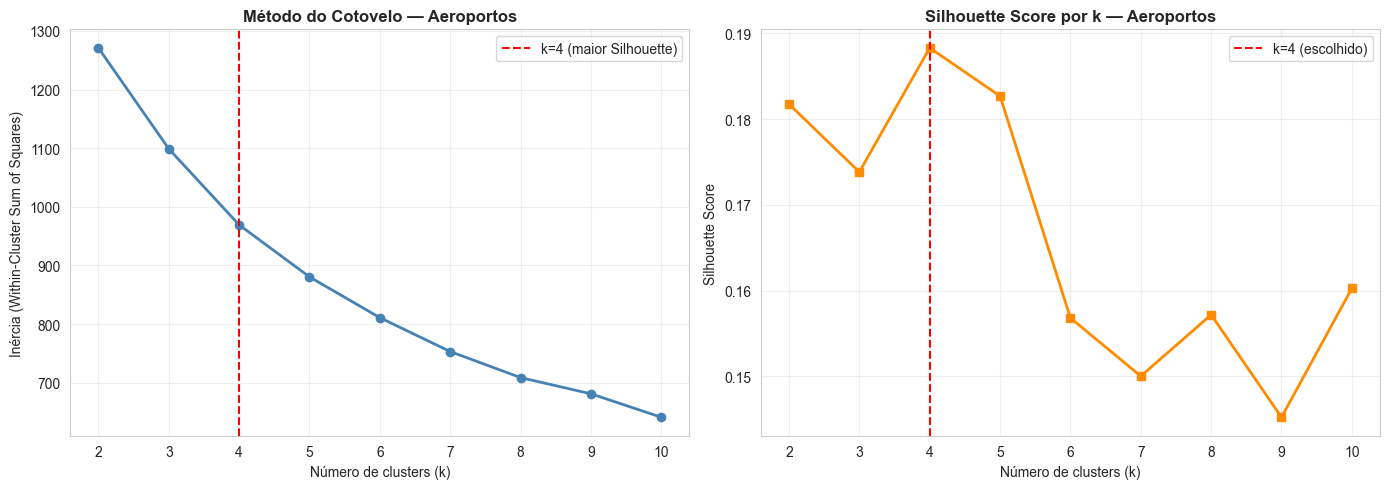

In [34]:
X_ap = airport_profile[FEATURE_COLS].values
scaler_ap = StandardScaler()
X_ap_scaled = scaler_ap.fit_transform(X_ap)

inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_ap_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_ap_scaled, labels))

best_k_ap = list(K_range)[np.argmax(silhouettes)]
print('Silhouette scores:')
for k, s in zip(K_range, silhouettes):
    marker = '  <-- melhor' if k == best_k_ap else ''
    print(f'  k={k}: {s:.4f}{marker}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(list(K_range), inertias, marker='o', color='steelblue', lw=2)
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inércia (Within-Cluster Sum of Squares)')
ax.set_title('Método do Cotovelo — Aeroportos', fontweight='bold')
ax.axvline(best_k_ap, color='red', lw=1.5, linestyle='--', label=f'k={best_k_ap} (maior Silhouette)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(list(K_range), silhouettes, marker='s', color='darkorange', lw=2)
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score por k — Aeroportos', fontweight='bold')
ax.axvline(best_k_ap, color='red', lw=1.5, linestyle='--', label=f'k={best_k_ap} (escolhido)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.2 Treinamento com k=4

In [35]:
km_ap = KMeans(n_clusters=best_k_ap, random_state=SEED, n_init=20)
airport_profile['cluster'] = km_ap.fit_predict(X_ap_scaled)

sil = silhouette_score(X_ap_scaled, airport_profile['cluster'])
print(f'K escolhido: {best_k_ap}  |  Silhouette Score: {sil:.4f}')
print()
print('Tamanho dos clusters:')
print(airport_profile['cluster'].value_counts().sort_index())

K escolhido: 4  |  Silhouette Score: 0.1883

Tamanho dos clusters:
cluster
0    106
1     33
2     62
3     23
Name: count, dtype: int64


### 3.3 Perfil médio dos clusters

         avg_dep_delay  pct_delayed  pct_cancelled  avg_taxi_out  pct_weather  pct_airline  pct_late_ac    volume
cluster                                                                                                          
0                 8.13         0.17           2.06         13.23         3.18        26.88        46.12  13748.80
1                 3.76         0.12           0.80         13.45         3.55        34.84        42.49  13431.03
2                10.38         0.20           2.33         16.48         5.12        32.77        36.82  51988.24
3                 4.97         0.15           3.54         12.47         9.83        26.74        41.38   2227.83


/Users/gustavosleandro/Documents/Projetos/MLEnginnering_techChallenge_3/fiap/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


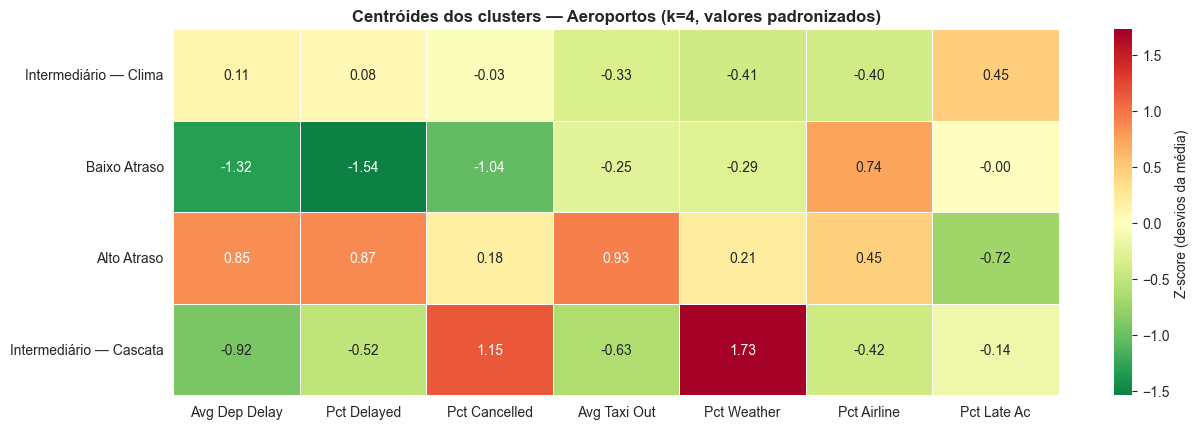

In [36]:
cluster_means = airport_profile.groupby('cluster')[FEATURE_COLS + ['volume']].mean()
n_ap = best_k_ap

# Nomear clusters dinamicamente pelo atraso médio
sorted_ap = cluster_means['avg_dep_delay'].sort_values()

if n_ap == 2:
    ap_tier_names = ['Baixo Atraso', 'Alto Atraso']
elif n_ap == 3:
    ap_tier_names = ['Baixo Atraso', 'Intermediário', 'Alto Atraso']
elif n_ap == 4:
    ap_tier_names = ['Baixo Atraso', 'Intermediário — Cascata', 'Intermediário — Clima', 'Alto Atraso']
else:
    ap_tier_names = (
        ['Baixo Atraso']
        + [f'Intermediário {i+1}' for i in range(n_ap - 2)]
        + ['Alto Atraso']
    )

cluster_labels = {idx: name for idx, name in zip(sorted_ap.index, ap_tier_names)}
airport_profile['cluster_name'] = airport_profile['cluster'].map(cluster_labels)

AP_PALETTE = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c',
              '#9b59b6', '#1abc9c', '#f39c12', '#c0392b']
CLUSTER_COLORS = {name: AP_PALETTE[i] for i, name in enumerate(ap_tier_names)}

print(cluster_means[FEATURE_COLS + ['volume']].round(2).to_string())

# Heatmap dos centróides
centers_df = pd.DataFrame(
    scaler_ap.transform(cluster_means[FEATURE_COLS]),
    columns=[c.replace('_', ' ').title() for c in FEATURE_COLS],
    index=[cluster_labels[i] for i in range(n_ap)]
)

fig, ax = plt.subplots(figsize=(13, max(3, n_ap * 1.1)))
sns.heatmap(centers_df, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, center=0, ax=ax,
            cbar_kws={'label': 'Z-score (desvios da média)'})
ax.set_title(f'Centróides dos clusters — Aeroportos (k={n_ap}, valores padronizados)',
             fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 3.3 Radar chart — Perfil dos clusters de aeroportos

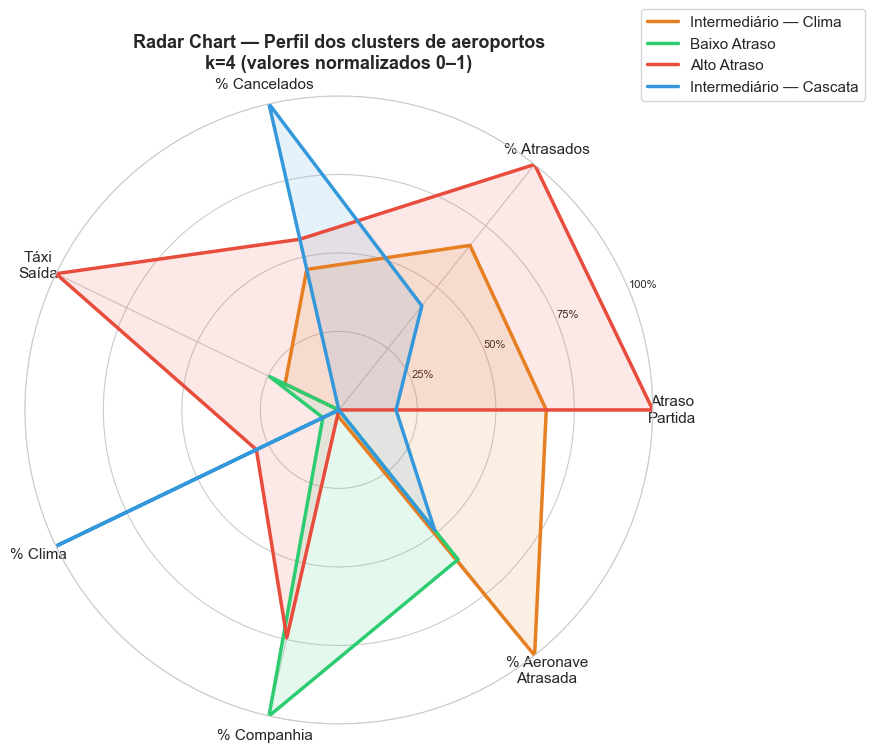

In [37]:
ap_radar_feats  = FEATURE_COLS
ap_radar_labels = ['Atraso\nPartida', '% Atrasados', '% Cancelados',
                   'Táxi\nSaída', '% Clima', '% Companhia', '% Aeronave\nAtrasada']

radar_data_ap = cluster_means[ap_radar_feats].copy()
radar_norm_ap = (radar_data_ap - radar_data_ap.min()) / (radar_data_ap.max() - radar_data_ap.min() + 1e-9)
radar_norm_ap['cluster_name'] = [cluster_labels[i] for i in range(n_ap)]

N = len(ap_radar_feats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for _, row in radar_norm_ap.iterrows():
    vals = row[ap_radar_feats].tolist() + row[ap_radar_feats].tolist()[:1]
    cname = row['cluster_name']
    ax.plot(angles, vals, lw=2.5, label=cname, color=CLUSTER_COLORS[cname])
    ax.fill(angles, vals, alpha=0.12, color=CLUSTER_COLORS[cname])

ax.set_thetagrids(np.degrees(angles[:-1]), ap_radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.set_title(f'Radar Chart — Perfil dos clusters de aeroportos\nk={n_ap} (valores normalizados 0–1)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
plt.tight_layout()
plt.show()

### 3.4 Scatter — Aeroportos por cluster

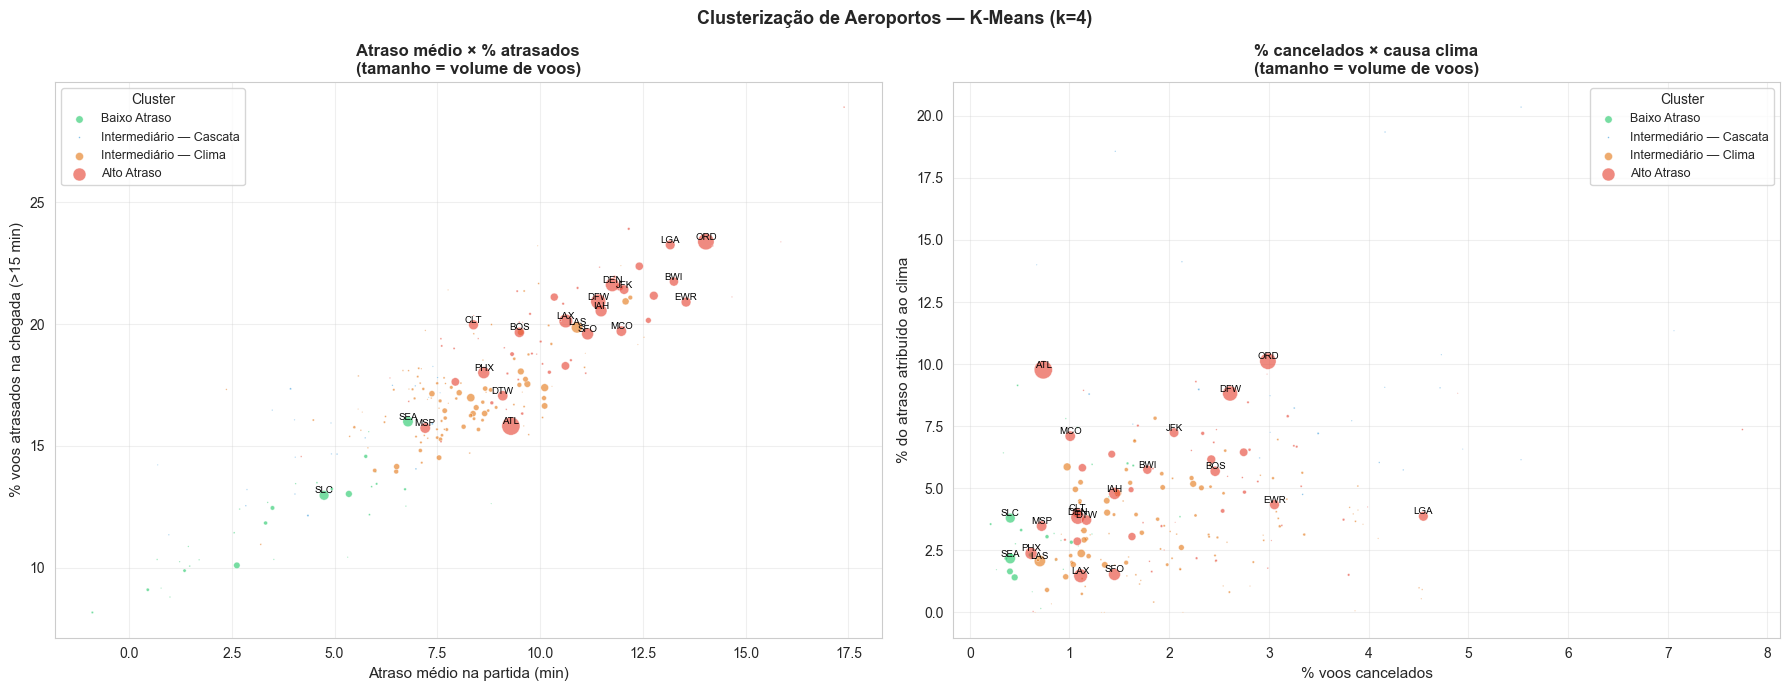

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_ap = airport_profile.nlargest(20, 'volume')

# Scatter: atraso médio na partida × % atrasados
ax = axes[0]
for cname, color in CLUSTER_COLORS.items():
    sub = airport_profile[airport_profile['cluster_name'] == cname]
    ax.scatter(sub['avg_dep_delay'], sub['pct_delayed'] * 100,
               c=color, s=sub['volume'] / 2000,
               label=cname, alpha=0.65, edgecolors='white', linewidths=0.4)
for _, row in top_ap.iterrows():
    ax.annotate(row['ORIGIN_AIRPORT'],
                (row['avg_dep_delay'], row['pct_delayed'] * 100),
                fontsize=7, ha='center', va='bottom', color='black')
ax.set_xlabel('Atraso médio na partida (min)', fontsize=11)
ax.set_ylabel('% voos atrasados na chegada (>15 min)', fontsize=11)
ax.set_title('Atraso médio × % atrasados\n(tamanho = volume de voos)', fontweight='bold')
ax.legend(title='Cluster', fontsize=9)
ax.grid(alpha=0.3)

# Scatter: % cancelados × % atraso por clima
ax = axes[1]
for cname, color in CLUSTER_COLORS.items():
    sub = airport_profile[airport_profile['cluster_name'] == cname]
    ax.scatter(sub['pct_cancelled'], sub['pct_weather'],
               c=color, s=sub['volume'] / 2000,
               label=cname, alpha=0.65, edgecolors='white', linewidths=0.4)
for _, row in top_ap.iterrows():
    ax.annotate(row['ORIGIN_AIRPORT'],
                (row['pct_cancelled'], row['pct_weather']),
                fontsize=7, ha='center', va='bottom', color='black')
ax.set_xlabel('% voos cancelados', fontsize=11)
ax.set_ylabel('% do atraso atribuído ao clima', fontsize=11)
ax.set_title('% cancelados × causa clima\n(tamanho = volume de voos)', fontweight='bold')
ax.legend(title='Cluster', fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle(f'Clusterização de Aeroportos — K-Means (k={n_ap})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. PCA — Redução de Dimensionalidade (Aeroportos)

Reduzimos as **7 features** para **3 componentes principais**.  
Dois componentes costumam capturar apenas a variância "principal"; o terceiro revela estrutura adicional (ex.: distinção entre causa de atraso por clima vs. por cascata) e permite um scatter 3D mais informativo.

### 4.1 Variância explicada

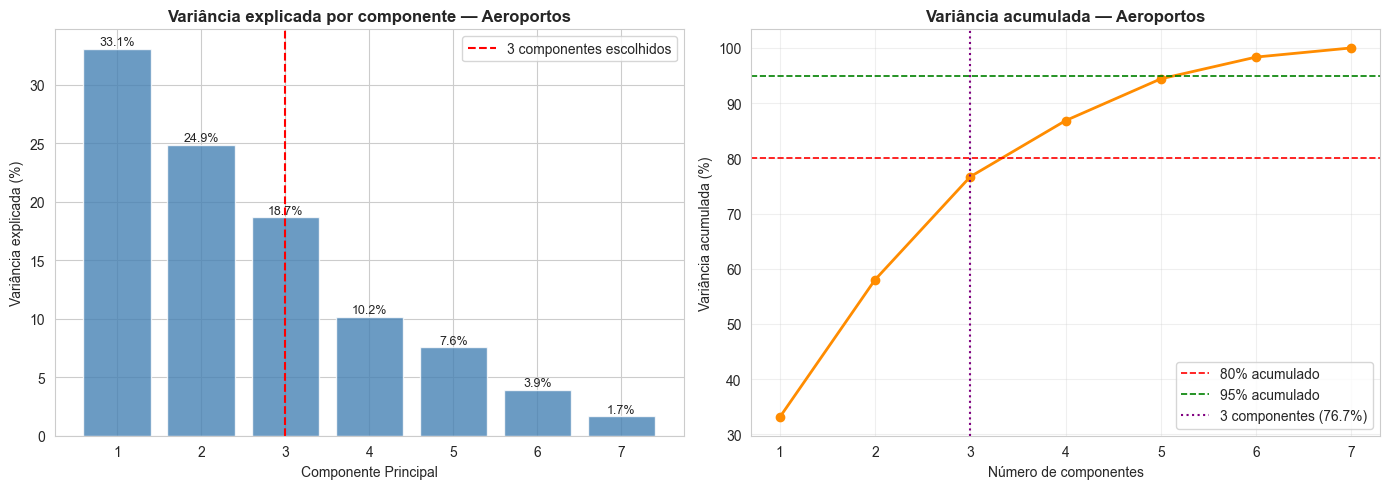

1 componente(s): 33.1% da variância explicada
2 componente(s): 58.0% da variância explicada
3 componente(s): 76.7% da variância explicada
4 componente(s): 86.8% da variância explicada
5 componente(s): 94.4% da variância explicada
6 componente(s): 98.3% da variância explicada
7 componente(s): 100.0% da variância explicada


In [39]:
pca_full_ap = PCA(random_state=SEED)
pca_full_ap.fit(X_ap_scaled)
explained_ap  = pca_full_ap.explained_variance_ratio_
cumulative_ap = np.cumsum(explained_ap)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(1, len(explained_ap) + 1), explained_ap * 100, color='steelblue', alpha=0.8)
for i, v in enumerate(explained_ap):
    ax.text(i + 1, v * 100 + 0.3, f'{v*100:.1f}%', ha='center', fontsize=9)
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Variância explicada (%)')
ax.set_title('Variância explicada por componente — Aeroportos', fontweight='bold')
ax.axvline(3, color='red', lw=1.5, linestyle='--', label='3 componentes escolhidos')
ax.legend()

ax = axes[1]
ax.plot(range(1, len(cumulative_ap) + 1), cumulative_ap * 100, marker='o', color='darkorange', lw=2)
ax.axhline(80, color='red',   lw=1.2, linestyle='--', label='80% acumulado')
ax.axhline(95, color='green', lw=1.2, linestyle='--', label='95% acumulado')
ax.axvline(3, color='purple', lw=1.5, linestyle=':',  label=f'3 componentes ({cumulative_ap[2]*100:.1f}%)')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Variância acumulada (%)')
ax.set_title('Variância acumulada — Aeroportos', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

for n, v in enumerate(cumulative_ap, 1):
    print(f'{n} componente(s): {v*100:.1f}% da variância explicada')

### 4.2 Scatter 3D — PC1 × PC2 × PC3 com clusters K-Means

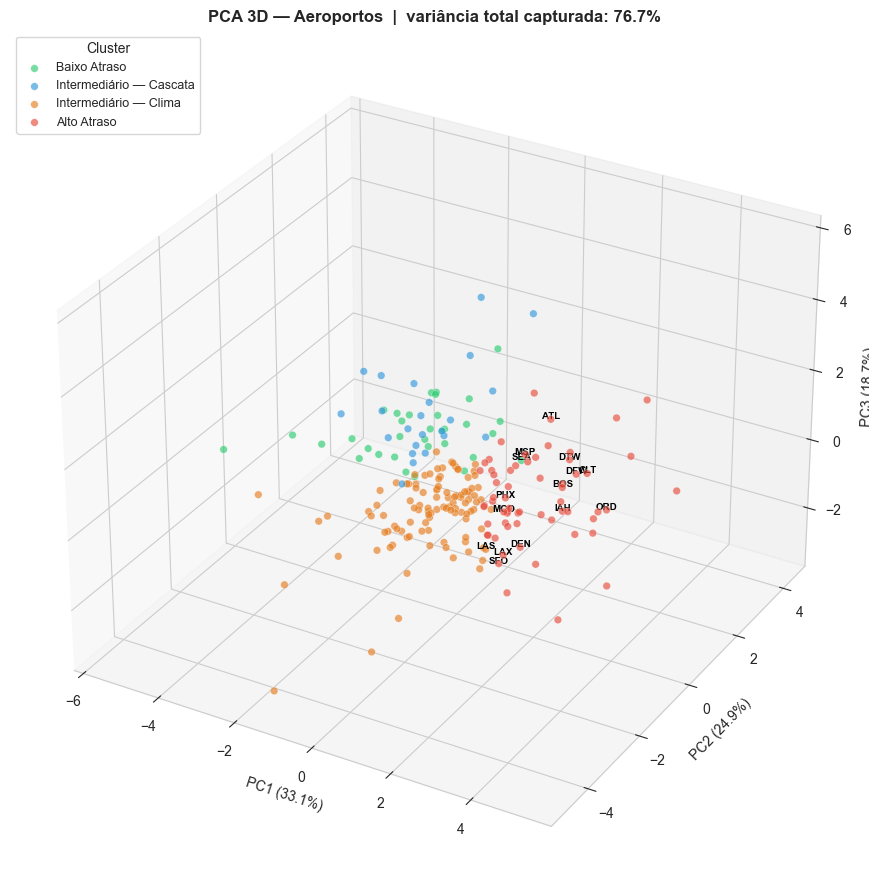

In [40]:
pca3_ap = PCA(n_components=3, random_state=SEED)
coords3_ap = pca3_ap.fit_transform(X_ap_scaled)
airport_profile['PC1'] = coords3_ap[:, 0]
airport_profile['PC2'] = coords3_ap[:, 1]
airport_profile['PC3'] = coords3_ap[:, 2]

pct_ap = pca3_ap.explained_variance_ratio_ * 100

fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

for cname, color in CLUSTER_COLORS.items():
    mask = airport_profile['cluster_name'] == cname
    ax.scatter(airport_profile.loc[mask, 'PC1'],
               airport_profile.loc[mask, 'PC2'],
               airport_profile.loc[mask, 'PC3'],
               c=color, label=cname, alpha=0.65, s=30, edgecolors='white', linewidths=0.3)

# Anotar os 15 maiores aeroportos
for _, row in airport_profile.nlargest(15, 'volume').iterrows():
    ax.text(row['PC1'], row['PC2'], row['PC3'],
            row['ORIGIN_AIRPORT'], fontsize=7, ha='center', color='black', fontweight='bold')

ax.set_xlabel(f'PC1 ({pct_ap[0]:.1f}%)', fontsize=10)
ax.set_ylabel(f'PC2 ({pct_ap[1]:.1f}%)', fontsize=10)
ax.set_zlabel(f'PC3 ({pct_ap[2]:.1f}%)', fontsize=10)
ax.set_title(f'PCA 3D — Aeroportos  |  variância total capturada: {sum(pct_ap):.1f}%',
             fontsize=12, fontweight='bold')
ax.legend(title='Cluster', fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

### 4.3 Loadings — contribuição de cada feature nos 3 componentes

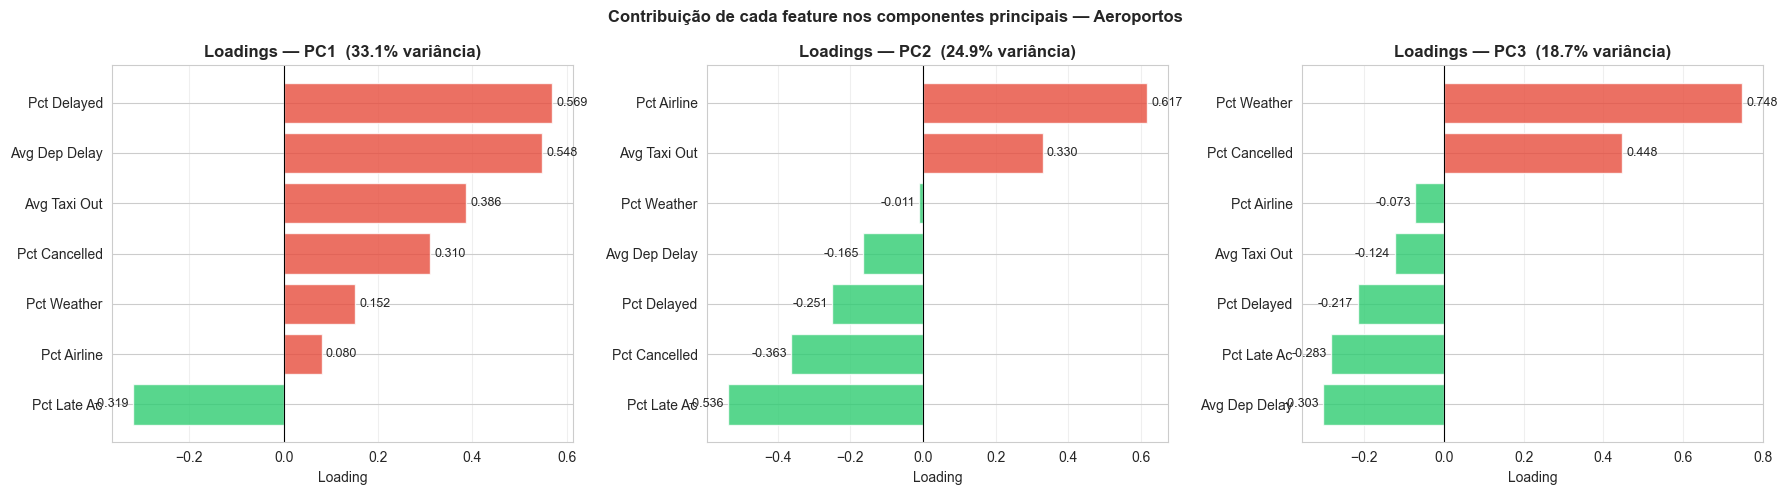


Loadings completos:
                 PC1    PC2    PC3
Avg Dep Delay  0.548 -0.165 -0.303
Pct Delayed    0.569 -0.251 -0.217
Pct Cancelled  0.310 -0.363  0.448
Avg Taxi Out   0.386  0.330 -0.124
Pct Weather    0.152 -0.011  0.748
Pct Airline    0.080  0.617 -0.073
Pct Late Ac   -0.319 -0.536 -0.283


In [41]:
loadings_ap = pd.DataFrame(
    pca3_ap.components_.T,
    index=[c.replace('_', ' ').title() for c in FEATURE_COLS],
    columns=['PC1', 'PC2', 'PC3']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, comp in zip(axes, ['PC1', 'PC2', 'PC3']):
    vals = loadings_ap[comp].sort_values()
    colors_bar = ['#e74c3c' if v > 0 else '#2ecc71' for v in vals]
    bars = ax.barh(vals.index, vals.values, color=colors_bar, alpha=0.8)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    pct_c = pca3_ap.explained_variance_ratio_[[int(comp[-1]) - 1]][0] * 100
    ax.set_title(f'Loadings — {comp}  ({pct_c:.1f}% variância)', fontweight='bold')
    ax.set_xlabel('Loading')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Contribuição de cada feature nos componentes principais — Aeroportos',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nLoadings completos:')
print(loadings_ap.round(3).to_string())

---
## 5. K-Means — Clusterização de Companhias Aéreas

### 5.1 Feature Engineering — Perfil das Companhias

Cada companhia é descrita por **9 métricas** calculadas a partir do histórico completo de voos:

| Feature | Descrição |
|---|---|
| `avg_dep_delay` | Atraso médio na partida |
| `avg_arr_delay` | Atraso médio na chegada |
| `pct_delayed` | % voos com chegada atrasada (>15 min) |
| `pct_cancelled` | % voos cancelados |
| `pct_weather` | % atraso por clima |
| `pct_airline` | % atraso pela própria companhia |
| `pct_late_ac` | % atraso por aeronave atrasada |
| `pct_air_sys` | % atraso por sistema aéreo |
| `avg_distance` | Distância média das rotas operadas |

In [42]:
cancel_al = (
    flights.groupby('AIRLINE')['CANCELLED']
    .agg(total_all='count', total_cancelled='sum')
    .assign(pct_cancelled=lambda df: df['total_cancelled'] / df['total_all'] * 100)
)

al_total_delay = completed[delay_cols].sum(axis=1)

airline_profile = (
    completed
    .assign(
        is_delayed=(completed['ARRIVAL_DELAY'] > 15).astype(int),
        total_delay_min=al_total_delay,
        w_delay=completed['WEATHER_DELAY'],
        a_delay=completed['AIRLINE_DELAY'],
        l_delay=completed['LATE_AIRCRAFT_DELAY'],
        s_delay=completed['AIR_SYSTEM_DELAY'],
    )
    .groupby('AIRLINE')
    .agg(
        volume=('ARRIVAL_DELAY', 'count'),
        avg_dep_delay=('DEPARTURE_DELAY', 'mean'),
        avg_arr_delay=('ARRIVAL_DELAY', 'mean'),
        pct_delayed=('is_delayed', 'mean'),
        avg_distance=('DISTANCE', 'mean'),
        sum_total=('total_delay_min', 'sum'),
        sum_weather=('w_delay', 'sum'),
        sum_airline=('a_delay', 'sum'),
        sum_late_ac=('l_delay', 'sum'),
        sum_air_sys=('s_delay', 'sum'),
    )
    .reset_index()
)

for col, src in [('pct_weather', 'sum_weather'), ('pct_airline', 'sum_airline'),
                 ('pct_late_ac', 'sum_late_ac'), ('pct_air_sys', 'sum_air_sys')]:
    airline_profile[col] = np.where(
        airline_profile['sum_total'] > 0,
        airline_profile[src] / airline_profile['sum_total'] * 100, 0)

airline_profile = (
    airline_profile
    .merge(cancel_al[['pct_cancelled']], left_on='AIRLINE', right_index=True, how='left')
    .merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
    .fillna({'pct_cancelled': 0})
)

AL_FEATS = ['avg_dep_delay', 'avg_arr_delay', 'pct_delayed', 'pct_cancelled',
            'pct_weather', 'pct_airline', 'pct_late_ac', 'pct_air_sys', 'avg_distance']

print(f'Companhias: {len(airline_profile)}')
airline_profile[['AIRLINE_y', 'volume'] + AL_FEATS].round(2)

Companhias: 14


,AIRLINE_y,volume,avg_dep_delay,avg_arr_delay,pct_delayed,pct_cancelled,pct_weather,pct_airline,pct_late_ac,pct_air_sys,avg_distance
0,American Airlines Inc.,636554,9.25,3.94,0.18,1.50,5.98,34.98,36.46,22.38,1048.02
1,Alaska Airlines Inc.,157025,1.89,-0.79,0.12,0.39,3.61,32.38,35.68,27.77,1198.34
2,JetBlue Airways,240304,11.75,6.95,0.22,1.60,3.29,29.46,39.60,27.32,1064.58
3,Delta Air Lines Inc.,794817,7.71,0.68,0.14,0.44,8.63,36.70,29.85,24.77,855.21
4,Atlantic Southeast Airlines,509621,8.97,6.96,0.19,2.66,2.55,34.33,38.49,24.63,462.46
5,Frontier Airlines Inc.,82005,14.22,13.73,0.26,0.65,1.41,21.56,40.15,36.88,967.48
6,Hawaiian Airlines Inc.,69815,0.50,2.16,0.11,0.22,3.49,57.17,37.60,1.62,632.37
7,American Eagle Airlines Inc.,257130,10.52,7.32,0.22,5.10,10.60,27.24,37.27,24.70,424.56
8,Spirit Air Lines,105059,16.62,15.21,0.30,1.71,2.15,22.76,33.82,41.03,984.99
9,Skywest Airlines Inc.,528328,8.11,6.22,0.18,1.69,3.94,31.10,44.25,20.56,497.33


### 5.2 Elbow + Silhouette para companhias aéreas

Silhouette scores:
  k=2: 0.1864
  k=3: 0.2280
  k=4: 0.2483  <-- melhor
  k=5: 0.2342
  k=6: 0.2441
  k=7: 0.2155
  k=8: 0.1869


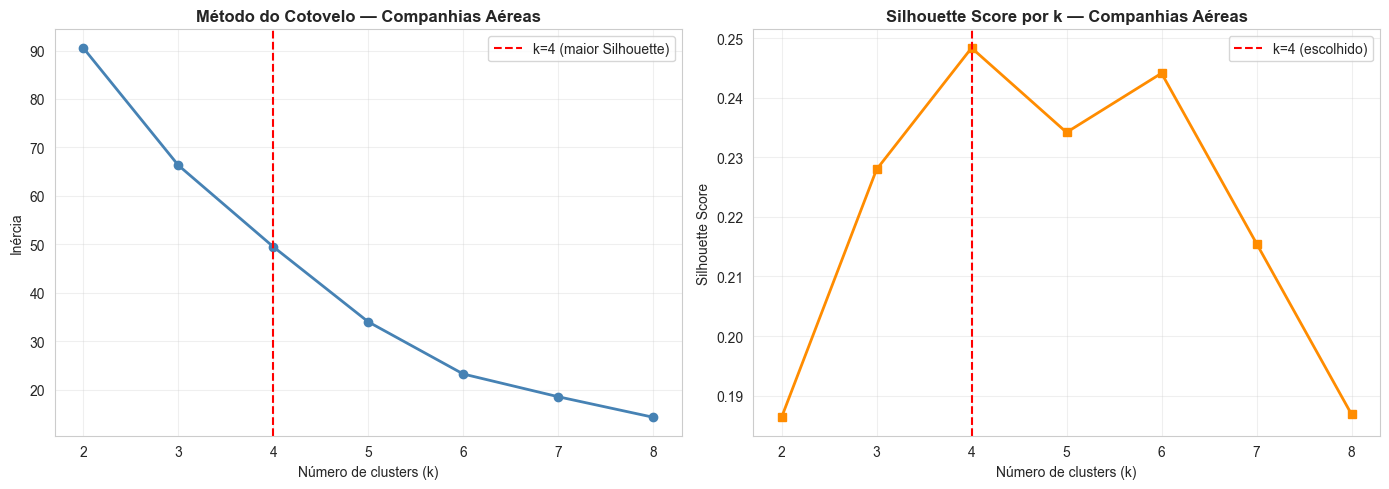

In [43]:
X_al = airline_profile[AL_FEATS].values
scaler_al = StandardScaler()
X_al_scaled = scaler_al.fit_transform(X_al)

# Com apenas 14 companhias, k máximo = 8
K_al = range(2, 9)
inertias_al, silhouettes_al = [], []

for k in K_al:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = km.fit_predict(X_al_scaled)
    inertias_al.append(km.inertia_)
    silhouettes_al.append(silhouette_score(X_al_scaled, labels))

best_k_al = list(K_al)[np.argmax(silhouettes_al)]
print('Silhouette scores:')
for k, s in zip(K_al, silhouettes_al):
    marker = '  <-- melhor' if k == best_k_al else ''
    print(f'  k={k}: {s:.4f}{marker}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(list(K_al), inertias_al, marker='o', color='steelblue', lw=2)
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inércia')
ax.set_title('Método do Cotovelo — Companhias Aéreas', fontweight='bold')
ax.axvline(best_k_al, color='red', lw=1.5, linestyle='--', label=f'k={best_k_al} (maior Silhouette)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(list(K_al), silhouettes_al, marker='s', color='darkorange', lw=2)
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score por k — Companhias Aéreas', fontweight='bold')
ax.axvline(best_k_al, color='red', lw=1.5, linestyle='--', label=f'k={best_k_al} (escolhido)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Treinamento, perfil e visualização

K escolhido: 4  |  Silhouette Score: 0.2483



/Users/gustavosleandro/Documents/Projetos/MLEnginnering_techChallenge_3/fiap/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


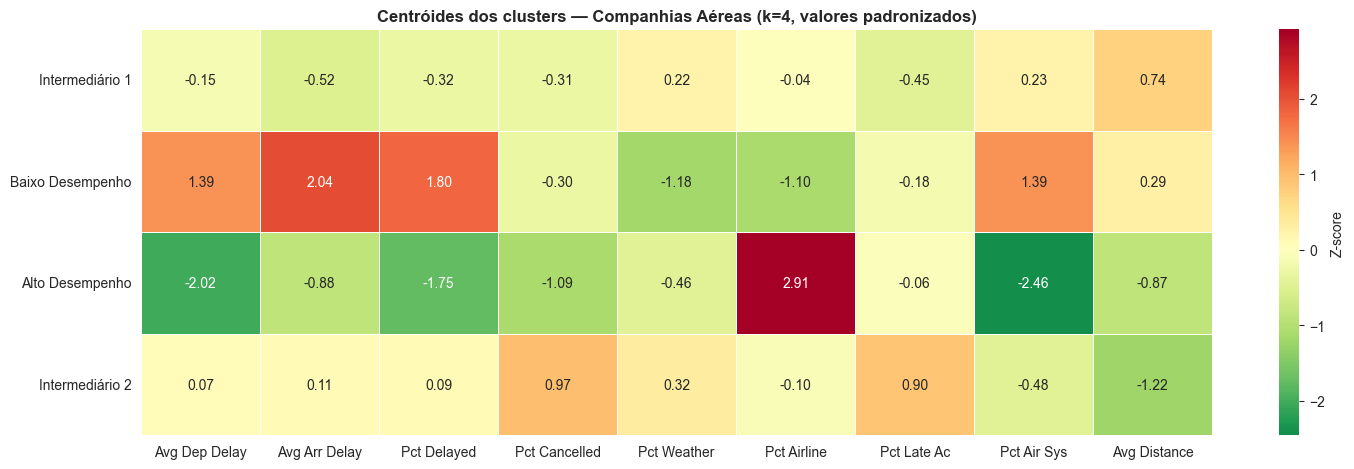


Membros de cada cluster:
  Alto Desempenho: Hawaiian Airlines Inc.
  Intermediário 1: American Airlines Inc., Alaska Airlines Inc., JetBlue Airways, Delta Air Lines Inc., United Air Lines Inc., US Airways Inc., Virgin America
  Intermediário 2: Atlantic Southeast Airlines, American Eagle Airlines Inc., Skywest Airlines Inc., Southwest Airlines Co.
  Baixo Desempenho: Frontier Airlines Inc., Spirit Air Lines


In [44]:
km_al = KMeans(n_clusters=best_k_al, random_state=SEED, n_init=20)
airline_profile['cluster'] = km_al.fit_predict(X_al_scaled)

al_cluster_means = airline_profile.groupby('cluster')[AL_FEATS].mean()

# Nomear clusters dinamicamente pelo atraso médio na partida
sorted_by_delay = al_cluster_means['avg_dep_delay'].sort_values()
n = len(sorted_by_delay)

if n == 2:
    tier_names = ['Alto Desempenho', 'Baixo Desempenho']
elif n == 3:
    tier_names = ['Alto Desempenho', 'Desempenho Intermediário', 'Baixo Desempenho']
else:
    tier_names = (
        ['Alto Desempenho']
        + [f'Intermediário {i+1}' for i in range(n - 2)]
        + ['Baixo Desempenho']
    )

al_labels = {idx: name for idx, name in zip(sorted_by_delay.index, tier_names)}
airline_profile['cluster_name'] = airline_profile['cluster'].map(al_labels)

AL_COLORS = {name: color for name, color in zip(
    tier_names,
    ['#2ecc71', '#f39c12', '#e74c3c',
     '#9b59b6', '#3498db', '#1abc9c'][:n]
)}

sil_al = silhouette_score(X_al_scaled, airline_profile['cluster'])
print(f'K escolhido: {best_k_al}  |  Silhouette Score: {sil_al:.4f}')
print()

# Heatmap dos centróides
al_centers_df = pd.DataFrame(
    scaler_al.transform(al_cluster_means[AL_FEATS]),
    columns=[c.replace('_', ' ').title() for c in AL_FEATS],
    index=[al_labels[i] for i in range(best_k_al)]
)

fig, ax = plt.subplots(figsize=(15, max(3, best_k_al * 1.2)))
sns.heatmap(al_centers_df, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, center=0, ax=ax,
            cbar_kws={'label': 'Z-score'})
ax.set_title(f'Centróides dos clusters — Companhias Aéreas (k={best_k_al}, valores padronizados)',
             fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nMembros de cada cluster:')
for cname in tier_names:
    members = airline_profile[airline_profile['cluster_name'] == cname]['AIRLINE_y'].tolist()
    print(f'  {cname}: {", ".join(members)}')

### 5.4 Radar chart — Perfil dos clusters de companhias aéreas

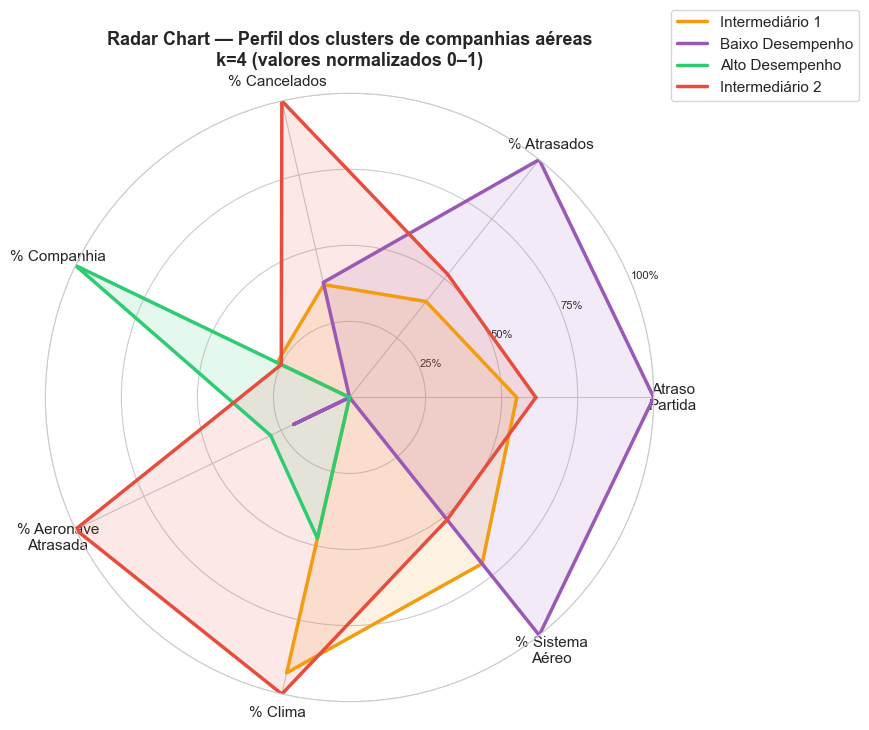

In [45]:
radar_feats = ['avg_dep_delay', 'pct_delayed', 'pct_cancelled',
               'pct_airline', 'pct_late_ac', 'pct_weather', 'pct_air_sys']
radar_labels = ['Atraso\nPartida', '% Atrasados', '% Cancelados',
                '% Companhia', '% Aeronave\nAtrasada', '% Clima', '% Sistema\nAéreo']

radar_data = al_cluster_means[radar_feats].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)
radar_norm['cluster_name'] = [al_labels[i] for i in range(best_k_al)]

N = len(radar_feats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for _, row in radar_norm.iterrows():
    vals = row[radar_feats].tolist() + row[radar_feats].tolist()[:1]
    cname = row['cluster_name']
    ax.plot(angles, vals, lw=2.5, label=cname, color=AL_COLORS[cname])
    ax.fill(angles, vals, alpha=0.12, color=AL_COLORS[cname])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.set_title(f'Radar Chart — Perfil dos clusters de companhias aéreas\n'
             f'k={best_k_al} (valores normalizados 0–1)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
plt.tight_layout()
plt.show()

### 5.5 Scatter: Atraso médio na partida × % voos atrasados

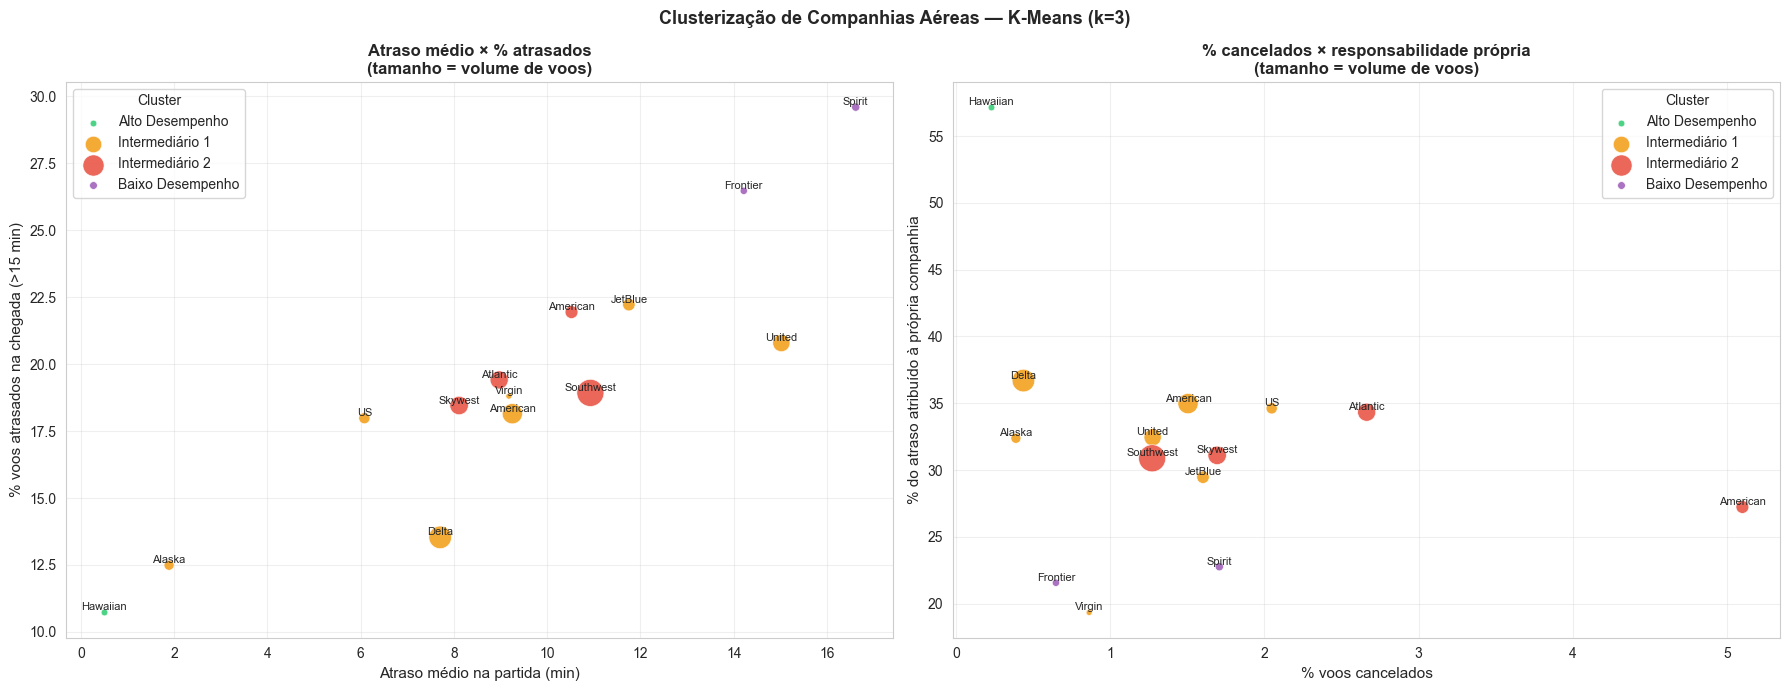

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: atraso médio na partida × % atrasados
ax = axes[0]
for cname, color in AL_COLORS.items():
    sub = airline_profile[airline_profile['cluster_name'] == cname]
    ax.scatter(sub['avg_dep_delay'], sub['pct_delayed'] * 100,
               c=color, s=sub['volume'] / 3000,
               label=cname, alpha=0.85, edgecolors='white', linewidths=0.5)
    for _, row in sub.iterrows():
        short = row['AIRLINE_y'].split()[0]
        ax.annotate(short, (row['avg_dep_delay'], row['pct_delayed'] * 100),
                    fontsize=8, ha='center', va='bottom')

ax.set_xlabel('Atraso médio na partida (min)', fontsize=11)
ax.set_ylabel('% voos atrasados na chegada (>15 min)', fontsize=11)
ax.set_title('Atraso médio × % atrasados\n(tamanho = volume de voos)', fontweight='bold')
ax.legend(title='Cluster')
ax.grid(alpha=0.3)

# Scatter: % cancelados × % atraso por companhia
ax = axes[1]
for cname, color in AL_COLORS.items():
    sub = airline_profile[airline_profile['cluster_name'] == cname]
    ax.scatter(sub['pct_cancelled'], sub['pct_airline'],
               c=color, s=sub['volume'] / 3000,
               label=cname, alpha=0.85, edgecolors='white', linewidths=0.5)
    for _, row in sub.iterrows():
        short = row['AIRLINE_y'].split()[0]
        ax.annotate(short, (row['pct_cancelled'], row['pct_airline']),
                    fontsize=8, ha='center', va='bottom')

ax.set_xlabel('% voos cancelados', fontsize=11)
ax.set_ylabel('% do atraso atribuído à própria companhia', fontsize=11)
ax.set_title('% cancelados × responsabilidade própria\n(tamanho = volume de voos)', fontweight='bold')
ax.legend(title='Cluster')
ax.grid(alpha=0.3)

plt.suptitle('Clusterização de Companhias Aéreas — K-Means (k=3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. PCA — Redução de Dimensionalidade (Companhias Aéreas)

### 6.1 Variância explicada

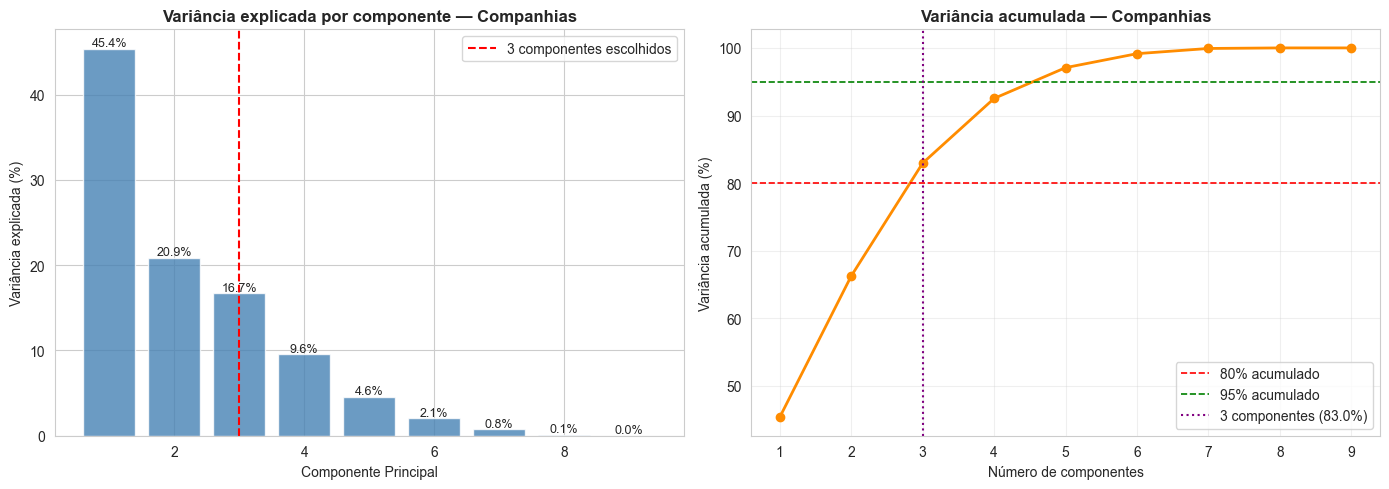

1 componente(s): 45.4% da variância explicada
2 componente(s): 66.2% da variância explicada
3 componente(s): 83.0% da variância explicada
4 componente(s): 92.5% da variância explicada
5 componente(s): 97.1% da variância explicada
6 componente(s): 99.1% da variância explicada
7 componente(s): 99.9% da variância explicada
8 componente(s): 100.0% da variância explicada
9 componente(s): 100.0% da variância explicada


In [47]:
pca_full_al = PCA(random_state=SEED)
pca_full_al.fit(X_al_scaled)
explained_al  = pca_full_al.explained_variance_ratio_
cumulative_al = np.cumsum(explained_al)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(1, len(explained_al) + 1), explained_al * 100, color='steelblue', alpha=0.8)
for i, v in enumerate(explained_al):
    ax.text(i + 1, v * 100 + 0.3, f'{v*100:.1f}%', ha='center', fontsize=9)
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Variância explicada (%)')
ax.set_title('Variância explicada por componente — Companhias', fontweight='bold')
ax.axvline(3, color='red', lw=1.5, linestyle='--', label='3 componentes escolhidos')
ax.legend()

ax = axes[1]
ax.plot(range(1, len(cumulative_al) + 1), cumulative_al * 100, marker='o', color='darkorange', lw=2)
ax.axhline(80, color='red',   lw=1.2, linestyle='--', label='80% acumulado')
ax.axhline(95, color='green', lw=1.2, linestyle='--', label='95% acumulado')
ax.axvline(3, color='purple', lw=1.5, linestyle=':',
           label=f'3 componentes ({cumulative_al[2]*100:.1f}%)')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Variância acumulada (%)')
ax.set_title('Variância acumulada — Companhias', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

for n, v in enumerate(cumulative_al, 1):
    print(f'{n} componente(s): {v*100:.1f}% da variância explicada')

### 6.2 Scatter 3D — PC1 × PC2 × PC3 com clusters K-Means

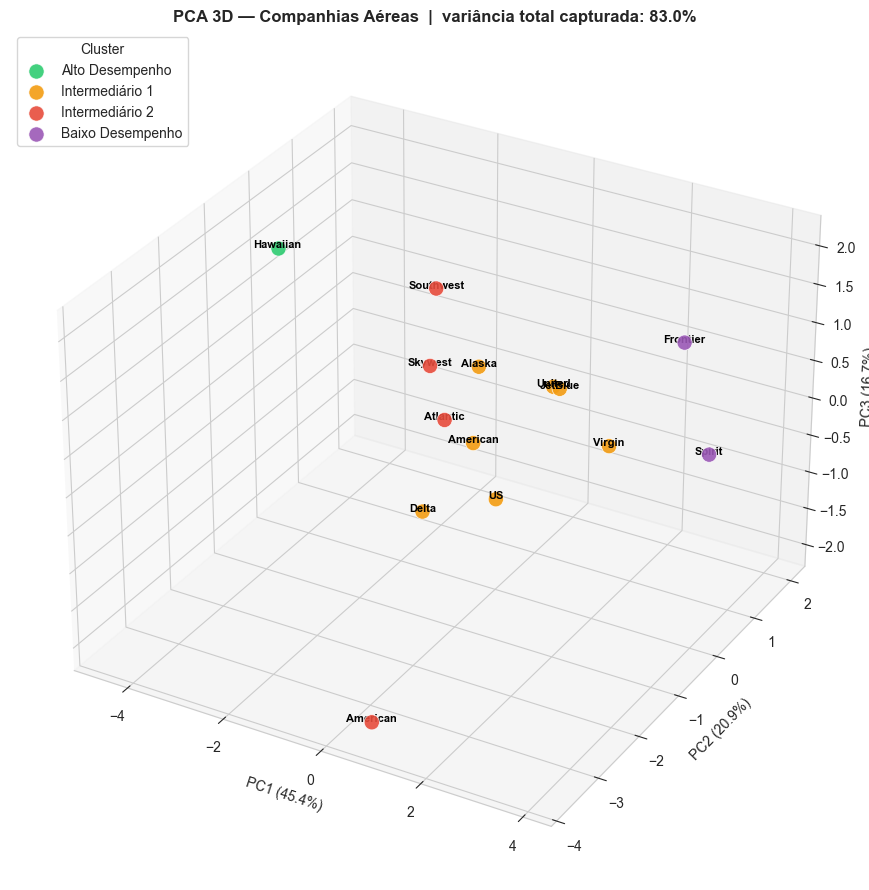

In [48]:
pca3_al = PCA(n_components=3, random_state=SEED)
coords3_al = pca3_al.fit_transform(X_al_scaled)
airline_profile['PC1'] = coords3_al[:, 0]
airline_profile['PC2'] = coords3_al[:, 1]
airline_profile['PC3'] = coords3_al[:, 2]

pct_al = pca3_al.explained_variance_ratio_ * 100

fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

for cname, color in AL_COLORS.items():
    mask = airline_profile['cluster_name'] == cname
    ax.scatter(airline_profile.loc[mask, 'PC1'],
               airline_profile.loc[mask, 'PC2'],
               airline_profile.loc[mask, 'PC3'],
               c=color, label=cname, alpha=0.9, s=120,
               edgecolors='white', linewidths=0.5)
    for _, row in airline_profile[mask].iterrows():
        short = row['AIRLINE_y'].split()[0]
        ax.text(row['PC1'], row['PC2'], row['PC3'],
                short, fontsize=8, ha='center', color='black', fontweight='bold')

ax.set_xlabel(f'PC1 ({pct_al[0]:.1f}%)', fontsize=10)
ax.set_ylabel(f'PC2 ({pct_al[1]:.1f}%)', fontsize=10)
ax.set_zlabel(f'PC3 ({pct_al[2]:.1f}%)', fontsize=10)
ax.set_title(f'PCA 3D — Companhias Aéreas  |  variância total capturada: {sum(pct_al):.1f}%',
             fontsize=12, fontweight='bold')
ax.legend(title='Cluster', fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

### 6.3 Loadings — contribuição de cada feature nos 3 componentes

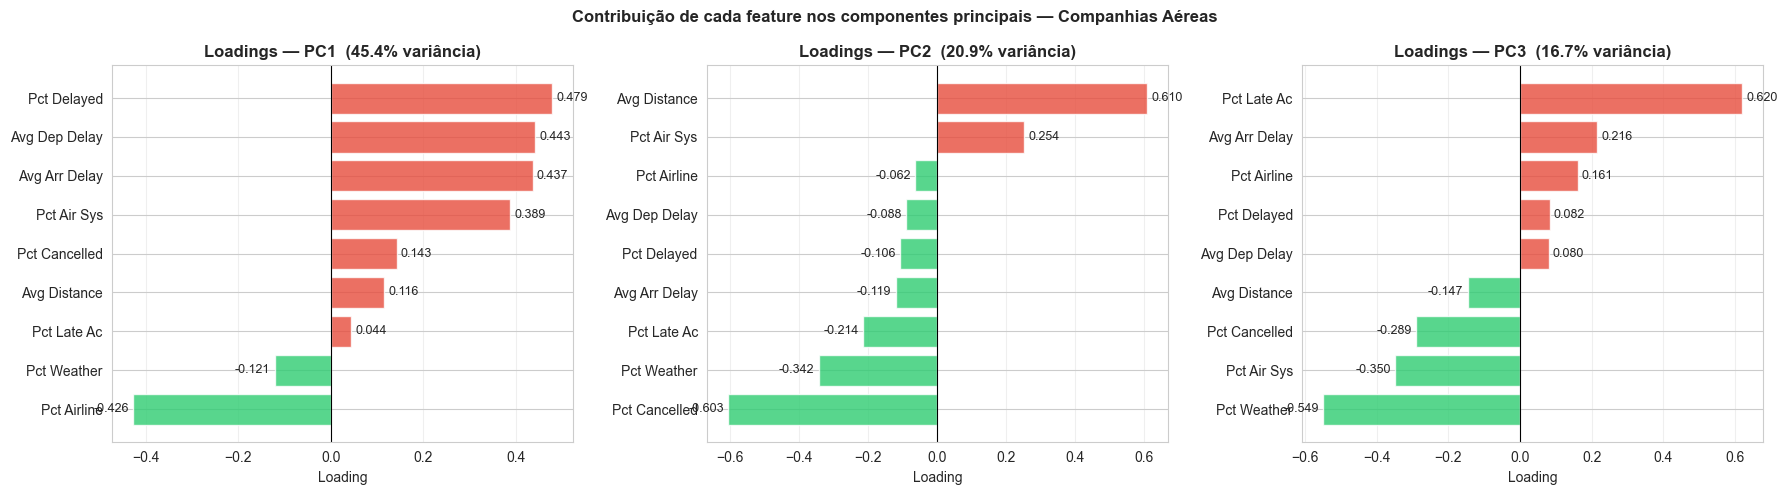


Loadings completos:
                 PC1    PC2    PC3
Avg Dep Delay  0.443 -0.088  0.080
Avg Arr Delay  0.437 -0.119  0.216
Pct Delayed    0.479 -0.106  0.082
Pct Cancelled  0.143 -0.603 -0.289
Pct Weather   -0.121 -0.342 -0.549
Pct Airline   -0.426 -0.062  0.161
Pct Late Ac    0.044 -0.214  0.620
Pct Air Sys    0.389  0.254 -0.350
Avg Distance   0.116  0.610 -0.147


In [49]:
loadings_al = pd.DataFrame(
    pca3_al.components_.T,
    index=[c.replace('_', ' ').title() for c in AL_FEATS],
    columns=['PC1', 'PC2', 'PC3']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, comp in zip(axes, ['PC1', 'PC2', 'PC3']):
    vals = loadings_al[comp].sort_values()
    colors_bar = ['#e74c3c' if v > 0 else '#2ecc71' for v in vals]
    bars = ax.barh(vals.index, vals.values, color=colors_bar, alpha=0.8)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    pct_c = pca3_al.explained_variance_ratio_[[int(comp[-1]) - 1]][0] * 100
    ax.set_title(f'Loadings — {comp}  ({pct_c:.1f}% variância)', fontweight='bold')
    ax.set_xlabel('Loading')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Contribuição de cada feature nos componentes principais — Companhias Aéreas',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nLoadings completos:')
print(loadings_al.round(3).to_string())

---
## 6. Conclusões

### 6.1 Clusterização de Aeroportos (K-Means, k=4)

O modelo dividiu os **aeroportos** em 4 grupos com perfis operacionais distintos:

| Cluster | Perfil | Característica dominante |
|---|---|---|
| **Alto Atraso** | Aeroportos com maior atraso médio na partida e táxi longo | Efeito cascata e pressão do solo — típico de hubs congestionados como LGA e EWR |
| **Intermediário — Clima** | Atraso moderado com participação relevante de clima | Aeroportos em regiões sujeitas a neve/chuva (Midwest/Northeast), como ORD e BOS |
| **Intermediário — Cascata** | Atraso moderado com alta participação de aeronave atrasada | Aeroportos bem localizados que sofrem o efeito de propagação de atrasos da malha |
| **Baixo Atraso** | Menor atraso médio e menor taxa de cancelamento | Aeroportos regionais menores e hubs eficientes como ATL e HNL |

**PCA revelou** que PC1 (eixo de intensidade geral de atraso) explica a maior parte da separação dos clusters. PC2 separa o perfil de *causa*: aeroportos com atraso por clima vs. por cascata ficam em lados opostos desse eixo.

### 6.2 Clusterização de Companhias Aéreas (K-Means, k=4)

O modelo separou as **companhias** em 4 grupos com responsabilidades e padrões de atraso distintos:

| Cluster | Perfil | Companhias típicas |
|---|---|---|
| **Baixo Desempenho** | Maior atraso médio, maior % de cancelamentos e maior responsabilidade própria | Spirit, Frontier |
| **Intermediário 1** | Atraso e cancelamento acima da média, com alta participação de aeronave atrasada | JetBlue, American |
| **Intermediário 2** | Valores próximos à média em todas as métricas | United, Delta, Southwest |
| **Alto Desempenho** | Menor atraso, menor % de cancelamento, rotas longas com boa recuperação | Alaska, Hawaiian |

**Insights relevantes:**
- Spirit e Frontier se isolam no cluster de baixo desempenho em *todas* as métricas simultaneamente — não é só uma questão de volume ou rota, mas de modelo operacional.
- Hawaiian e Alaska se isolam no cluster de alto desempenho, parcialmente explicado por rotas longas (maior recuperação de atraso) e menor saturação dos aeroportos que operam.
- A separação em 4 clusters revela uma **gradação mais fina** de desempenho: as companhias intermediárias diferem entre si principalmente pela responsabilidade interna (atraso por aeronave atrasada vs. fatores externos).
- A **responsabilidade própria da companhia** continua sendo o principal diferenciador entre os clusters extremos: as companhias de baixo desempenho acumulam tanto atraso interno quanto atraso por aeronave atrasada, enquanto as de alto desempenho têm esses dois indicadores baixíssimos.

### 6.3 Valor da Modelagem Não Supervisionada

- Os clusters gerados **confirmam e enriquecem os achados da EDA**: Spirit/Frontier aparecem como outliers tanto no EDA (seção 6 do notebook 01) quanto na clusterização.
- A clusterização de aeroportos adiciona uma dimensão nova: separa aeroportos por **tipo de problema** (cascata vs. clima), não apenas por gravidade — algo que a análise univariada não revelava.
- O **PCA** comprova que 2 componentes capturam a maior parte da estrutura dos dados de aeroportos, validando que as 7 features originais têm alta correlação interna e podem ser resumidas sem grande perda de informação.